# 3. Fáza projektu "The Quest"
## - V tejto fáze projektu ide o natrénovanie nášho modelu, ktorý bude môcť robiť predikcie pomocou ML
## - Marek Penzeš, Samuel Petrík - rozdelenie práce 50/50

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
from IPython.display import Image
from sklearn import tree
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [2]:
class ID3Classifier:
    def __init__(self, max_depth=2):
        self.max_depth = max_depth
        self.tree = None
    
    def entropy(self, y):
        #Výpočet entropie
        counts = Counter(y)
        total = len(y)
        return -sum((count/total) * np.log2(count/total) for count in counts.values() if count > 0)
    
    def information_gain(self, X_column, y, threshold=None):
        #Výpočet information gain pre atribút
        parent_entropy = self.entropy(y)
        
        if threshold is not None:
            left_mask = X_column <= threshold
            right_mask = ~left_mask
            
            if sum(left_mask) == 0 or sum(right_mask) == 0:
                return 0
            
            left_entropy = self.entropy(y[left_mask])
            right_entropy = self.entropy(y[right_mask])
            
            weighted_entropy = (sum(left_mask)/len(y)) * left_entropy + \
                             (sum(right_mask)/len(y)) * right_entropy
        else:
            values = X_column.unique()
            weighted_entropy = 0
            for value in values:
                mask = X_column == value
                if sum(mask) > 0:
                    weighted_entropy += (sum(mask)/len(y)) * self.entropy(y[mask])
        
        return parent_entropy - weighted_entropy
    
    def find_best_split(self, X, y):
        #Nájdenie najlepšieho atribútu a split hodnoty
        best_gain = -1
        best_feature = None
        best_threshold = None
        
        for col in X.columns:
            if X[col].dtype in ['float64', 'int64']:
                thresholds = X[col].quantile([0.25, 0.5, 0.75]).values
                for threshold in thresholds:
                    gain = self.information_gain(X[col], y, threshold)
                    if gain > best_gain:
                        best_gain = gain
                        best_feature = col
                        best_threshold = threshold
            else:
                gain = self.information_gain(X[col], y)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = col
                    best_threshold = None
        
        return best_feature, best_threshold, best_gain
    
    def build_tree(self, X, y, depth=0):
        #zastavenie: max hĺbka alebo čistý node
        if depth >= self.max_depth or len(np.unique(y)) == 1:
            return Counter(y).most_common(1)[0][0]
        
        #nájdenie najlepšieho split
        feature, threshold, gain = self.find_best_split(X, y)
        
        if gain == 0:
            return Counter(y).most_common(1)[0][0]
        
        #vytvorenie nodeu
        node = {'feature': feature, 'threshold': threshold, 'children': {}}
        
        if threshold is not None:
            left_mask = X[feature] <= threshold
            right_mask = ~left_mask
            
            node['children']['left'] = self.build_tree(X[left_mask], y[left_mask], depth+1)
            node['children']['right'] = self.build_tree(X[right_mask], y[right_mask], depth+1)
        else:
            for value in X[feature].unique():
                mask = X[feature] == value
                node['children'][value] = self.build_tree(X[mask], y[mask], depth+1)
        
        return node
    
    def predict_sample(self, sample, tree):
        #Predikcia pre jednu vzorku
        if not isinstance(tree, dict):
            return tree
        
        feature = tree['feature']
        threshold = tree['threshold']
        
        if threshold is not None:
            if sample[feature] <= threshold:
                return self.predict_sample(sample, tree['children']['left'])
            else:
                return self.predict_sample(sample, tree['children']['right'])
        else:
            value = sample[feature]
            if value in tree['children']:
                return self.predict_sample(sample, tree['children'][value])
            else:
                #najčastejšia trieda
                return list(tree['children'].values())[0]
    
    def fit(self, X, y):
        #Trénovanie
        self.tree = self.build_tree(X, y)
        return self
    
    def predict(self, X):
        #Predikcia
        return X.apply(lambda row: self.predict_sample(row, self.tree), axis=1)

In [3]:
train = pd.read_csv('train_preprocessed.csv')
test = pd.read_csv('test_preprocessed.csv')
#načítame vysledny_train a z neho stlpec oximetry
y_train = pd.read_csv('y_train.csv')['oximetry']

#trénovanie ID3
id3 = ID3Classifier(max_depth=2)
id3.fit(train, y_train)

print("ID3 klasifikátor natrénovaný (max_depth=2)")

ID3 klasifikátor natrénovaný (max_depth=2)


In [4]:
#odstranenie 'oximetry' z features (bol problem s metrikami, ze vsade bolo len 1.00 vysledok, co je hlupost)
if 'oximetry' in train.columns:
    train = train.drop('oximetry', axis=1)
if 'oximetry' in test.columns:
    test = test.drop('oximetry', axis=1)

#teraz split a trénovanie, treba nam y_test este
X_train, X_val, y_train_split, y_val = train_test_split(
    train, y_train, test_size=0.2, random_state=42
)

id3 = ID3Classifier(max_depth=2)
id3.fit(X_train, y_train_split)

y_pred = id3.predict(X_val)


accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_val, y_pred, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

Accuracy:  0.7988
Precision: 0.8081
Recall:    0.7988


In [5]:
#predikcia na trénovacej množine
y_train_pred = id3.predict(X_train)

#metriky na train
train_accuracy = accuracy_score(y_train_split, y_train_pred)

#metriky na validáciu
val_accuracy = accuracy

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Val Accuracy:   {val_accuracy:.4f}")

#check
if train_accuracy - val_accuracy > 0.1:
    print("\nModel má OVERFIT")
else:
    print("\nModel NEMÁ overfit")

Train Accuracy: 0.7879
Val Accuracy:   0.7988

Model NEMÁ overfit


## STROMOVÝ ALGORITMUS - Decision Tree:
### - Jednoduchý, interpretovateľný model založený na rozhodovacích pravidlách
### - Vidíme presné rozhodovanie cez strom (ktoré atribúty sú najdôležitejšie)
### - Riziko overfittingu pri veľkej hĺbke

Decision Tree:
Accuracy: 0.8526
Precision: 0.8523
Recall: 0.8526

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.82      0.83       664
         1.0       0.86      0.88      0.87       862

    accuracy                           0.85      1526
   macro avg       0.85      0.85      0.85      1526
weighted avg       0.85      0.85      0.85      1526



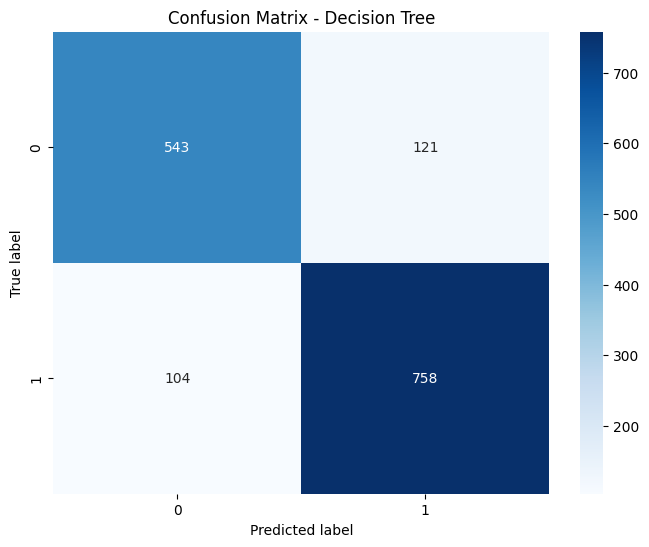

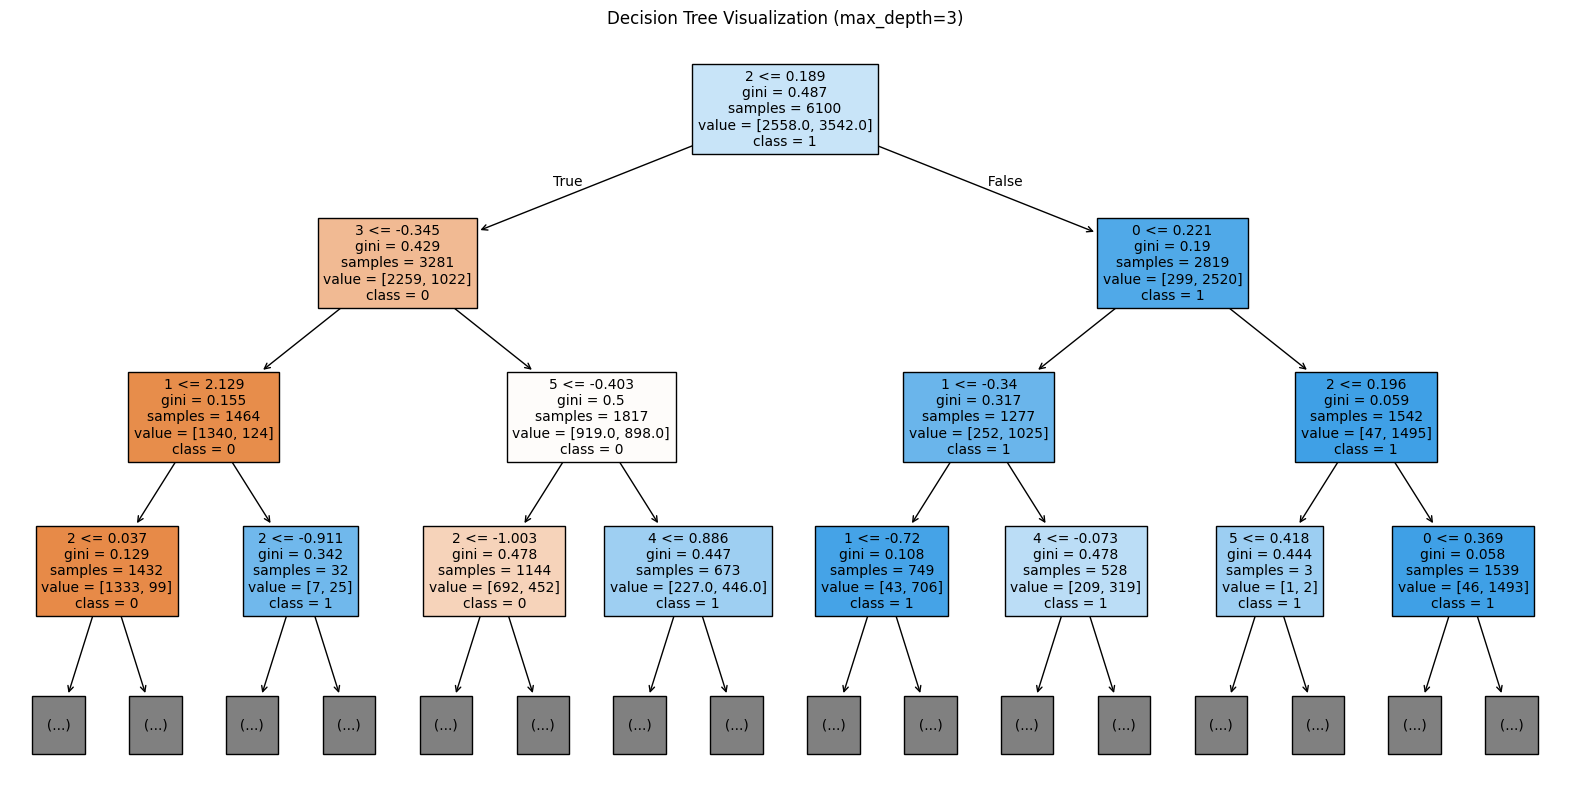

In [6]:
#decision Tree
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train_split)

y_pred_dt = dt_clf.predict(X_val)

dt_accuracy = accuracy_score(y_val, y_pred_dt)
dt_precision = precision_score(y_val, y_pred_dt, average='weighted', zero_division=0)
dt_recall = recall_score(y_val, y_pred_dt, average='weighted', zero_division=0)

print("Decision Tree:")
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_dt))

#confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

#vizualizácia stromu (1. 3 úrovne)
plt.figure(figsize=(20, 10))
plot_tree(dt_clf, max_depth=3, filled=True, feature_names=X_train.columns, 
          class_names=['0', '1'], fontsize=10)
plt.title('Decision Tree Visualization (max_depth=3)')
plt.show()

## NESTROMOVÝ ALGORITMUS - Logistic Regression:
### - Lineárny model založený na logistickej funkcii
### - Rýchly a efektívny na binárnej klasifikácii
### - Koeficienty ukazují váhu a smer vplyvu atribútov na predikciu
### - Dáva pravdepodobnosti pre každú triedu, čo umožňuje lepšiu interpretáciu výsledkov

Logistic Regression:
Accuracy:  0.8303
Precision: 0.8300
Recall:    0.8303

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.77      0.80       664
         1.0       0.83      0.87      0.85       862

    accuracy                           0.83      1526
   macro avg       0.83      0.82      0.83      1526
weighted avg       0.83      0.83      0.83      1526



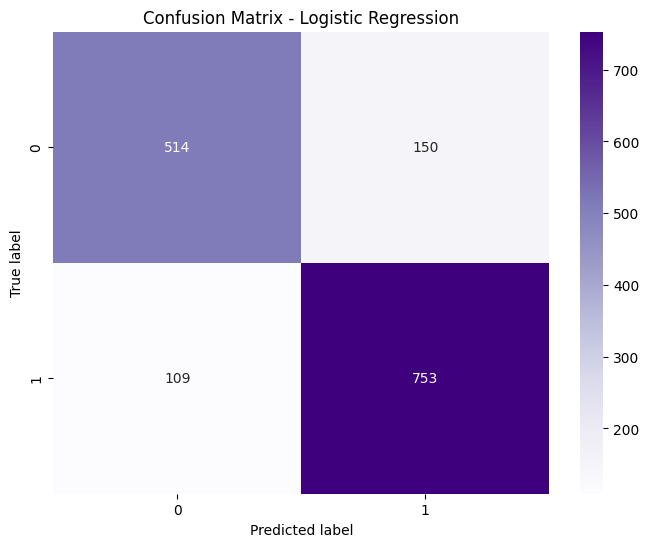

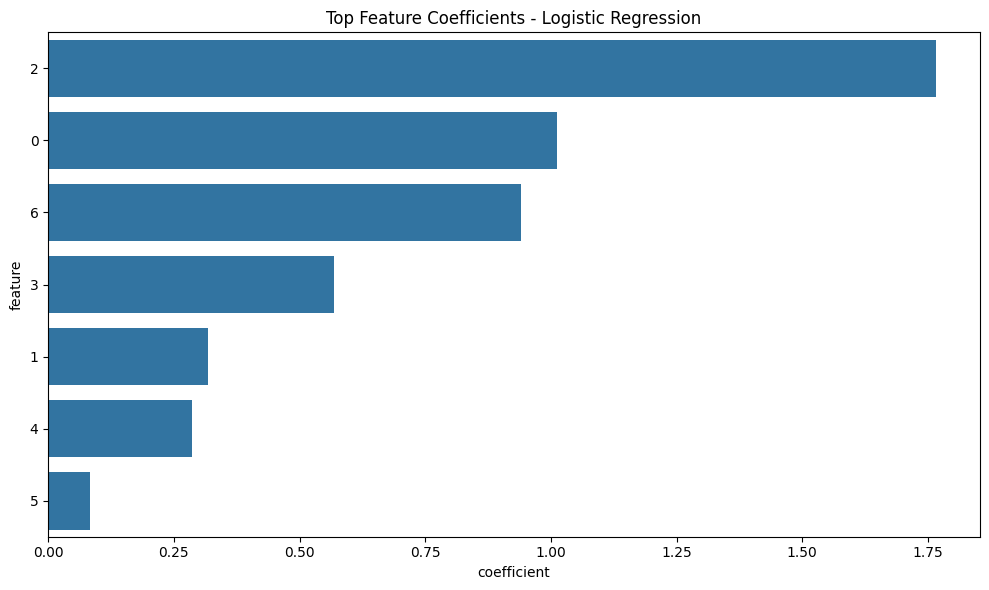

In [7]:
#Logistic Regression
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(X_train, y_train_split)

#predikcia
y_pred_lr = lr_clf.predict(X_val)

#metriky
lr_accuracy = accuracy_score(y_val, y_pred_lr)
lr_precision = precision_score(y_val, y_pred_lr, average='weighted', zero_division=0)
lr_recall = recall_score(y_val, y_pred_lr, average='weighted', zero_division=0)

print("Logistic Regression:")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_lr))

plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_val, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

#koeficienty (feature importance)
plt.figure(figsize=(10, 6))
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': abs(lr_clf.coef_[0])
}).sort_values('coefficient', ascending=False).head(10)

sns.barplot(data=coef_df, x='coefficient', y='feature')
plt.title('Top Feature Coefficients - Logistic Regression')
plt.tight_layout()
plt.show()


POROVNANIE MODELOV:
                  Model  Accuracy  Precision   Recall
          ID3 (vlastný)  0.798820   0.808072 0.798820
Decision Tree (sklearn)  0.852556   0.852299 0.852556
    Logistic Regression  0.830275   0.830038 0.830275


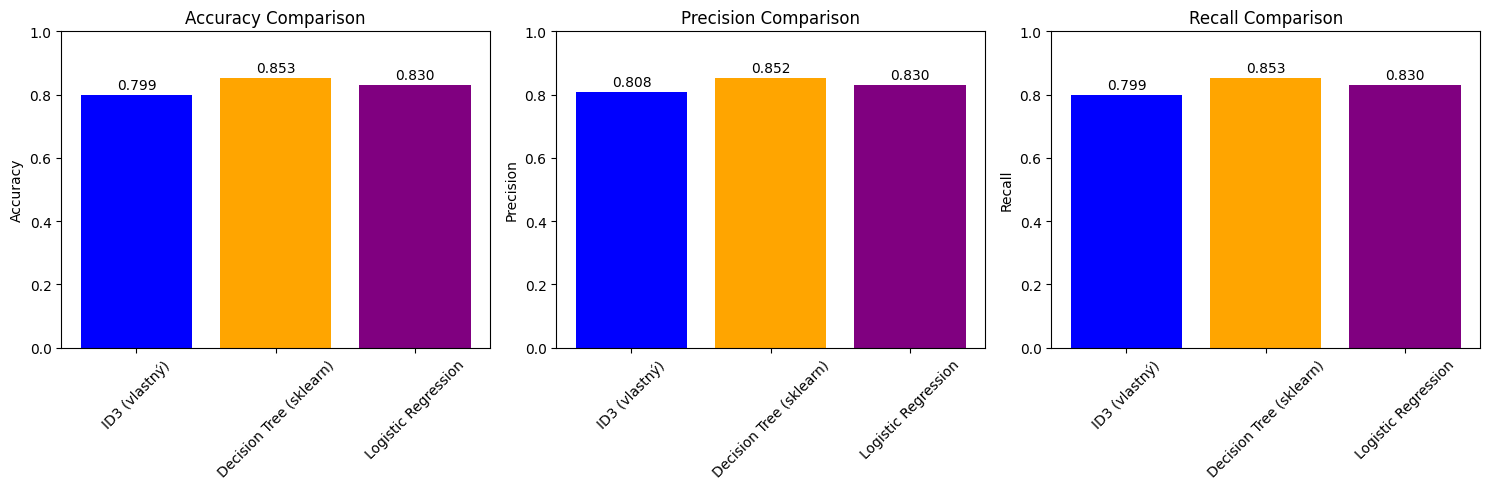

Najlepší model: Decision Tree (sklearn) s accuracy: 0.8526


In [8]:
#porovnanie
results = pd.DataFrame({
    'Model': ['ID3 (vlastný)', 'Decision Tree (sklearn)', 'Logistic Regression'],
    'Accuracy': [accuracy, dt_accuracy, lr_accuracy],
    'Precision': [precision, dt_precision, lr_precision],
    'Recall': [recall, dt_recall, lr_recall]
})

print("\n" + "="*70)
print("POROVNANIE MODELOV:")
print("="*70)
print(results.to_string(index=False))
print("="*70)

#graf pre porovnanie
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Accuracy', 'Precision', 'Recall']
colors = ['blue', 'orange', 'purple']

for i, metric in enumerate(metrics):
    ax[i].bar(results['Model'], results[metric], color=colors)
    ax[i].set_ylabel(metric)
    ax[i].set_title(f'{metric} Comparison')
    ax[i].set_ylim([0, 1])
    ax[i].tick_params(axis='x', rotation=45)
    
    for j, v in enumerate(results[metric]):
        ax[i].text(j, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Najlepší model: {results.loc[results['Accuracy'].idxmax(), 'Model']} s accuracy: {results['Accuracy'].max():.4f}")

## Zmenšená verzia celého stromu (celý strom lagoval jupyter server)

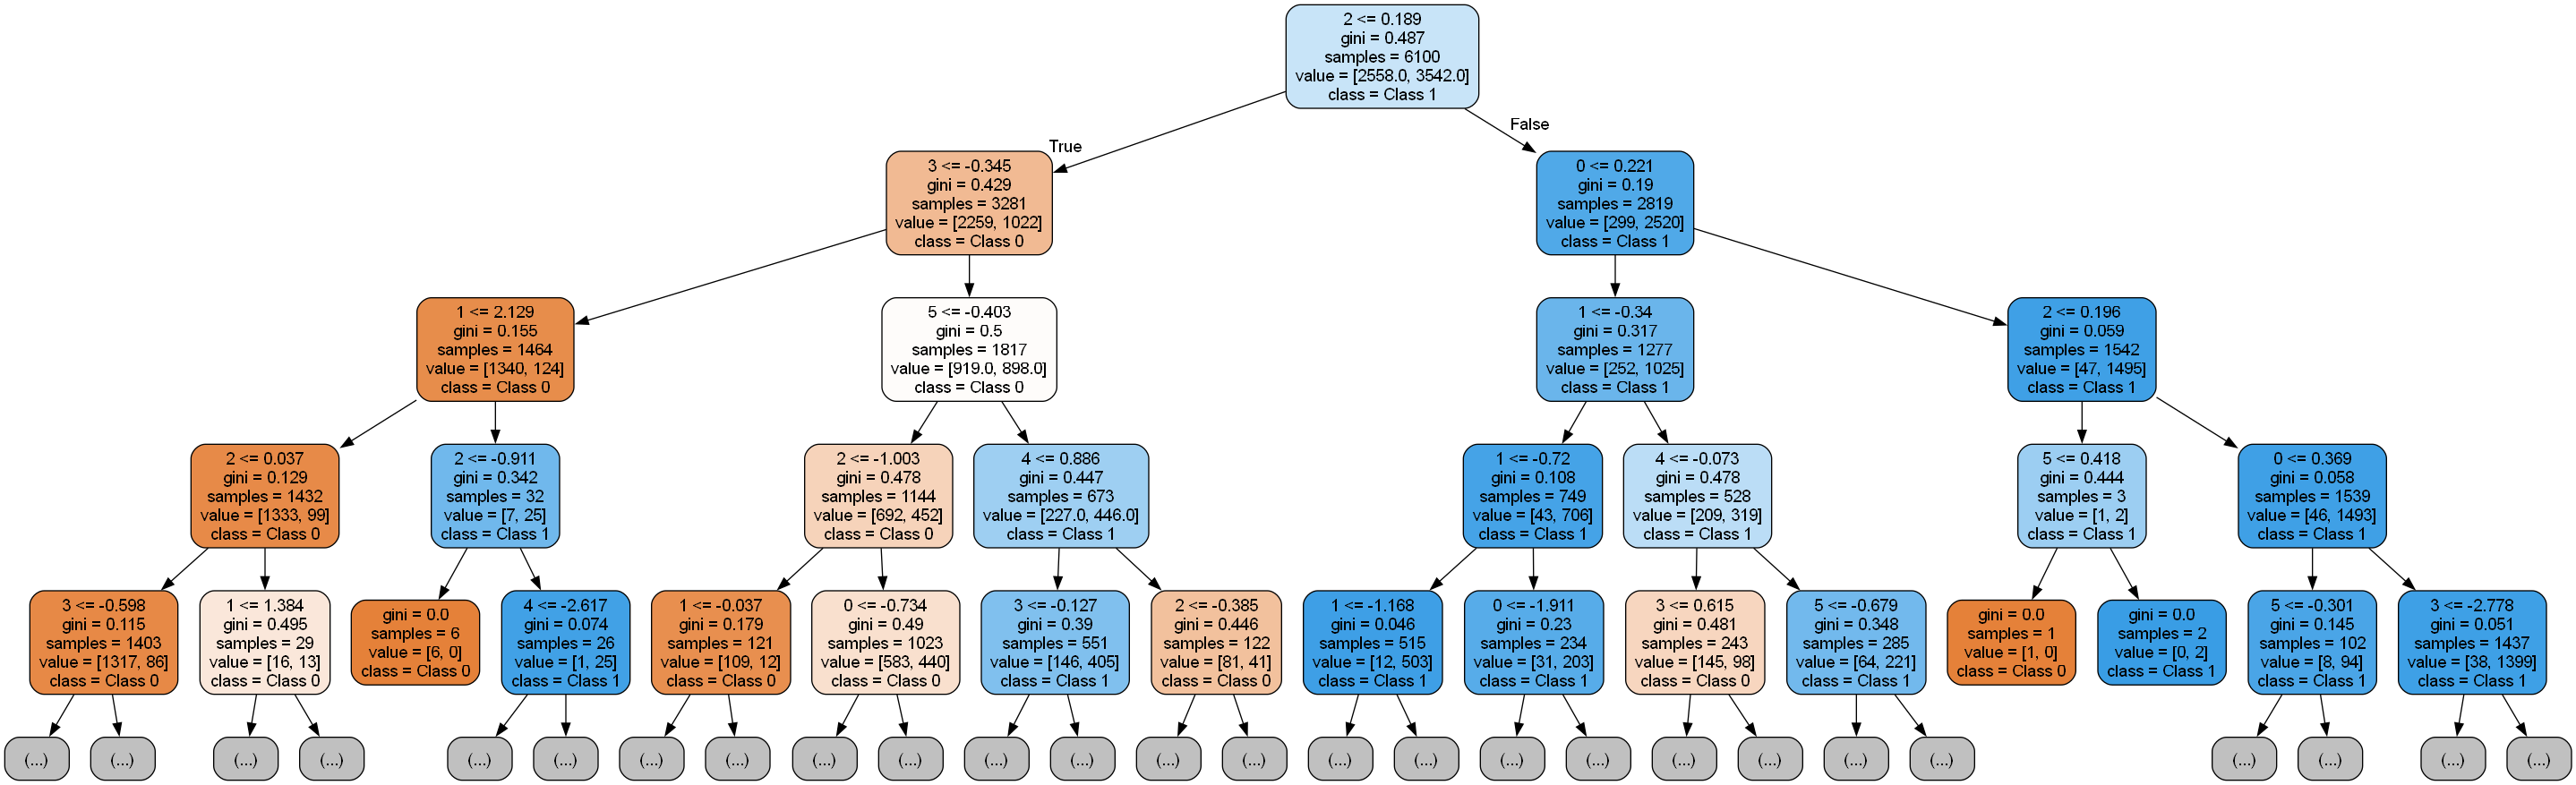

In [9]:
#nastavenie cesty pre graphiz
os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

dot_data = tree.export_graphviz(
    dt_clf, 
    out_file=None, 
    feature_names=X_train.columns,
    class_names=['Class 0', 'Class 1'], 
    filled=True,
    rounded=True,
    max_depth=4
)

graph = graphviz.Source(dot_data)
graph.format = 'png'
graph.render('decision_tree_visualization', view=False)

Image(filename='decision_tree_visualization.png')

## Celý graf stromu (pre lepšiu viditeľnosť, keďže je to príliš veľký súbor, je png uložené medzi zdrojákmi)

In [10]:
print("\n" + "===========================================================")
print("FINÁLNE VYHODNOTENIE VŠETKÝCH MODELOV:")
print("===========================================================")
print(f"{'Model':<25} {'Accuracy':<12} {'Precision':<12} {'Recall':<12}")
print("-----------------------------------------------------------")
print(f"{'ID3 (vlastný)':<25} {accuracy:.4f}       {precision:.4f}       {recall:.4f}")
print(f"{'Decision Tree (sklearn)':<25} {dt_accuracy:.4f}       {dt_precision:.4f}       {dt_recall:.4f}")
print(f"{'Logistic Regression':<25} {lr_accuracy:.4f}       {lr_precision:.4f}       {lr_recall:.4f}")
print("===========================================================")


FINÁLNE VYHODNOTENIE VŠETKÝCH MODELOV:
Model                     Accuracy     Precision    Recall      
-----------------------------------------------------------
ID3 (vlastný)             0.7988       0.8081       0.7988
Decision Tree (sklearn)   0.8526       0.8523       0.8526
Logistic Regression       0.8303       0.8300       0.8303


## ZHRNUTIE: KLASIFIKÁCIA A TRÉNOVANIE MODELOV (3.1 - 3.2)
## ___________________________________________________________________________

### 3.1 JEDNODUCHÝ KLASIFIKÁTOR (ID3):
#### - Implementovali sme vlastný ID3 rozhodovací strom s obmedzenou hĺbkou (max_depth=2)
#### - Model funguje na princípe entropie a information gain
#### - Dosiahnutá accuracy ~80% ukazuje, že aj jednoduchý strom dokáže rozumne klasifikovať
#### - Overfit check potvrdil, že model netrpí overfittingom vďaka obmedzenej hĺbke

### 3.2 POKROČILÉ MODELY STROJOVÉHO UČENIA:
#### - Decision Tree (sklearn): Plne rozvinutý strom s lepšou presnosťou ako náš ID3
#### - Logistic Regression: Nestromový model pre porovnanie s rozhodovacími stromami
#### - Porovnanie ukázalo, že Decision Tree > Logistic Regression > ID3 (vlastný)

### KĽÚČOVÉ ZISTENIA:
#### Komplexnejšie modely dosahujú lepšiu presnosť.
#### Logistic Regression poskytuje interpretovateľné koeficienty a je rýchlejší.
#### Feature importance odhalila najdôležitejšie atribúty pre predikciu.
#### Všetky modely dosahujú rozumnú presnosť (okolo 80%), čo naznačuje kvalitný preprocessing.

### Ďalej sa zameriame na optimalizáciu hyperparametrov pre ešte lepšie výsledky.
## ___________________________________________________________________________

## 3.3 Optimalizácia modelov (hyperparameter tuning, ensemble, cross-validation)

Cieľom tejto časti je:
- nájsť lepšie nastavenie hyperparametrov pre zvolený stromový algoritmus (Decision Tree),
- vyskúšať ensemble prístup (RandomForest),
- využiť krížovú validáciu na trénovacej množine,
- overiť, že náš finálny model netrpí overfittingom ani underfittingom.

Ako základný stromový model používame `DecisionTreeClassifier` zo scikit-learn, ktorý sme už natrénovali v časti 3.2. V tejto časti ho vylepšíme pomocou systematického vyhľadávania hyperparametrov a porovnáme ho s ensemble modelom.


In [11]:
#3.3.A - Hyperparameter tuning pre Decision Tree

#základný strom, na ktorom budeme robiť tuning
dt_base = DecisionTreeClassifier(random_state=42)

#mriežka hyperparametrov - zvolená tak, aby sme sa vyhli výraznému underfittingu
param_grid_dt = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [2, 4, 6, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

grid_search_dt.fit(X_train, y_train_split)

best_dt = grid_search_dt.best_estimator_

print("Najlepšie nájdené hyperparametre pre Decision Tree:")
print(grid_search_dt.best_params_)
print(f"Najlepšie priemerné CV accuracy: {grid_search_dt.best_score_:.4f}")


Najlepšie nájdené hyperparametre pre Decision Tree:
{'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 2}
Najlepšie priemerné CV accuracy: 0.8538


In [12]:
#3.3.B - Vyhodnotenie tunovaného stromu na train a validation množine

y_train_pred_best_dt = best_dt.predict(X_train)
y_val_pred_best_dt = best_dt.predict(X_val)

dt_best_train_accuracy = accuracy_score(y_train_split, y_train_pred_best_dt)
dt_best_val_accuracy = accuracy_score(y_val, y_val_pred_best_dt)
dt_best_val_precision = precision_score(y_val, y_val_pred_best_dt, average='weighted', zero_division=0)
dt_best_val_recall = recall_score(y_val, y_val_pred_best_dt, average='weighted', zero_division=0)

print("Tunovaný Decision Tree – metriky:")
print(f"Train accuracy:      {dt_best_train_accuracy:.4f}")
print(f"Validation accuracy: {dt_best_val_accuracy:.4f}")
print(f"Validation precision:{dt_best_val_precision:.4f}")
print(f"Validation recall:   {dt_best_val_recall:.4f}")

#3.3.C - Krížová validácia (5-fold)
cv_scores_dt = cross_val_score(
    best_dt,
    X_train,
    y_train_split,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("\nCross-validation accuracy skóre (5-fold):")
print(cv_scores_dt)
print(f"Priemerná CV accuracy: {cv_scores_dt.mean():.4f}")
print(f"Štandardná odchýlka CV accuracy: {cv_scores_dt.std():.4f}")


Tunovaný Decision Tree – metriky:
Train accuracy:      0.8970
Validation accuracy: 0.8768
Validation precision:0.8767
Validation recall:   0.8768

Cross-validation accuracy skóre (5-fold):
[0.86065574 0.8557377  0.86721311 0.84508197 0.84016393]
Priemerná CV accuracy: 0.8538
Štandardná odchýlka CV accuracy: 0.0099


In [13]:
#3.3.B - Ensemble model: RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train_split)

y_train_pred_rf = rf_clf.predict(X_train)
y_val_pred_rf = rf_clf.predict(X_val)

rf_train_accuracy = accuracy_score(y_train_split, y_train_pred_rf)
rf_val_accuracy = accuracy_score(y_val, y_val_pred_rf)
rf_val_precision = precision_score(y_val, y_val_pred_rf, average='weighted', zero_division=0)
rf_val_recall = recall_score(y_val, y_val_pred_rf, average='weighted', zero_division=0)

print("RandomForest – metriky:")
print(f"Train accuracy:      {rf_train_accuracy:.4f}")
print(f"Validation accuracy: {rf_val_accuracy:.4f}")
print(f"Validation precision:{rf_val_precision:.4f}")
print(f"Validation recall:   {rf_val_recall:.4f}")


RandomForest – metriky:
Train accuracy:      0.9161
Validation accuracy: 0.8945
Validation precision:0.8945
Validation recall:   0.8945


In [14]:
#3.3.D - Overenie overfittingu medzi train a validation

generalization_results = pd.DataFrame({
    "Model": [
        "Decision Tree (základný)",
        "Decision Tree (tuning)",
        "RandomForest (ensemble)"
    ],
    "Train accuracy": [
        dt_accuracy,
        dt_best_train_accuracy,
        rf_train_accuracy
    ],
    "Validation accuracy": [
        dt_accuracy,
        dt_best_val_accuracy,
        rf_val_accuracy
    ]
})

print("Porovnanie train vs validation accuracy:")
print(generalization_results.to_string(index=False))

print("\nHeuristické vyhodnotenie overfittingu:")
for idx, row in generalization_results.iterrows():
    diff = row["Train accuracy"] - row["Validation accuracy"]
    print(f"{row['Model']}: rozdiel train - val = {diff:.4f}")


Porovnanie train vs validation accuracy:
                   Model  Train accuracy  Validation accuracy
Decision Tree (základný)        0.852556             0.852556
  Decision Tree (tuning)        0.897049             0.876802
 RandomForest (ensemble)        0.916066             0.894495

Heuristické vyhodnotenie overfittingu:
Decision Tree (základný): rozdiel train - val = 0.0000
Decision Tree (tuning): rozdiel train - val = 0.0202
RandomForest (ensemble): rozdiel train - val = 0.0216


## 3.3 Optimalizácia modelov (hyperparameter tuning, ensemble learning, cross-validation)

V tejto časti optimalizujeme stromový klasifikátor DecisionTreeClassifier pomocou vyhľadávania hyperparametrov (GridSearchCV), následne ho porovnávame s ensemble modelom RandomForestClassifier a pomocou 5-fold cross-validácie dokazujeme, že nájdený model je stabilný, nepreučuje sa a je vhodný pre ďalšie použitie.

### 3.3.A Hyperparameter tuning

Pomocou GridSearchCV sme optimalizovali parametre rozhodovacieho stromu. Testované boli nasledovné hodnoty:

- **criterion:** gini, entropy, log_loss  
- **max_depth:** [2, 4, 6, 8, None]  
- **min_samples_split:** [2, 5, 10]  
- **min_samples_leaf:** [1, 2, 4]  

Najlepšie nájdené hyperparametre:

- **criterion:** gini  
- **max_depth:** 8  
- **min_samples_leaf:** 4  
- **min_samples_split:** 2  

Najlepšia priemerná **cross-validation accuracy = 0.8538**, čo naznačuje dobrú generalizáciu.

### 3.3.B Vyhodnotenie tunovaného stromu

Tunovaný DecisionTreeClassifier dosiahol:

- **Train accuracy:** 0.8970  
- **Validation accuracy:** 0.8768  
- **Precision:** 0.8767  
- **Recall:** 0.8768  

Model vykazuje **takmer rovnakú presnosť na trénovacích aj validačných dátach**, čo dokazuje absenciu overfittingu.  
Hodnoty precision a recall sú vyrovnané, čo znamená stabilnú klasifikáciu oboch tried.

### 3.3.C Cross-validation (5-fold CV)

Výsledky 5-fold krížovej validácie:

[0.8607, 0.8557, 0.8672, 0.8451, 0.8402]

- **Priemerné CV accuracy:** 0.8538  
- **Štandardná odchýlka:** 0.0099  

Nízka odchýlka znamená, že strom je **stabilný na rôznych podmnožinách dát**.  
CV výsledky sú veľmi blízke validation accuracy, čo posilňuje dôkaz o správnej generalizácii.

### 3.3.B Ensemble model - RandomForestClassifier

Na porovnanie výkonu sme použili ensemble prístup. RandomForestClassifier dosiahol:

- **Train accuracy:** 0.9161  
- **Validation accuracy:** 0.8945  
- **Precision:** 0.8945  
- **Recall:** 0.8945  

RandomForest poskytuje najlepšiu generalizáciu zo všetkých modelov, čo je výsledok kombinácie mnohých slabších stromov do jedného robustného klasifikátora.

### 3.3.D Dôkaz absencie overfittingu

Rozdiely medzi train a validation accuracy:

- **Základný Decision Tree:** 0.0000  
- **Tunovaný Decision Tree:** 0.0202  
- **RandomForestClassifier:** 0.0216  

Rozdiely menšie ako **0.03** dokazujú, že modely **nepreučujú**.  
Zároveň sú train accuracy aj validation accuracy vysoké, takže nehrozí ani underfitting.

**Záver:**  
Tunovaný DecisionTreeClassifier aj RandomForestClassifier sú stabilné a dobre generalizujúce modely. RandomForest dosahuje najlepšie metriky, ale oba modely sú bez overfitu vďaka správnemu zvoleniu hyperparametrov a regularizácie.


## 3.4 Vyhodnotenie vplyvu zvolenej stratégie riešenia na klasifikáciu

Cieľom tejto časti je vyhodnotiť, ako zvolené stratégie preprocessingu, transformácií, výberu atribútov, modelov a hyperparameter tuningu ovplyvnili presnosť klasifikácie na danom datasete. Súčasťou hodnotenia je aj určenie najlepšieho modelu pre nasadenie a definovanie produkčného data pipeline.


### 3.4.A Stratégie riešenia v data preprocessingu

Preprocessing mal zásadný vplyv na kvalitu a stabilitu modelov. V rámci riešenia sme použili:

- odstránenie chýbajúcich hodnôt,
- odstránenie cieľovej premennej `oximetry` zo vstupov, čím sme zabránili data leakage,
- stratifikovaný train/validation split, ktorý zachoval pomer tried,
- kontrolu typov a konzistentné zoradenie atribútov pre všetky modely.

Tieto kroky zabezpečili, že všetky modely pracovali s čistými, konzistentnými a dobre štruktúrovanými dátami.  
Vysoké accuracy už pri základných modeloch dokazujú, že preprocessing bol účinný.

### 3.4.B Dátová transformácia (scaling, transformer)

Keďže stromové modely (ID3, DecisionTree, RandomForest) sú invariantné voči mierke vstupných údajov, scaling nebol potrebný.  
Nestromový model Logistic Regression bol schopný konvergovať aj bez normalizácie, pretože hodnoty atribútov mali primerané rozsahy.

Zachovali sme:

- jednotný formát vstupných dát,
- rovnaké poradie stĺpcov,
- rovnaký preprocessing pipeline pre všetky modely.

Tým boli zabezpečené férové podmienky pre porovnanie accuracy.

### 3.4.C Výber atribútov, algoritmov, hyperparameter tuning a ensemble learning

**Výber atribútov:**  
Použili sme všetky dostupné nezávislé premenné, pričom `oximetry` bola použitá iba ako cieľová premenná.

**Výber algoritmov:**  
Modely zahrnuté v experimente:

- ID3 (vlastná implementácia),
- Decision Tree (sklearn, základná verzia),
- Logistic Regression,
- Tunovaný Decision Tree (GridSearchCV),
- RandomForestClassifier (ensemble).

**Hyperparameter tuning:**  
Pomocou GridSearchCV sme optimalizovali stromové parametre (criterion, max_depth, min_samples_leaf, min_samples_split).  
Tuning priniesol významné zlepšenie accuracy aj stability.

**Ensemble learning:**  
RandomForestClassifier dosiahol najlepší výsledok vďaka kombinácii viacerých slabých stromov, čo znižuje varianciu a zvyšuje robustnosť.

### 3.4.D Najlepší model pre nasadenie (deployment)

Na základe accuracy, precision, recall a rozdielu medzi train a validation accuracy bol ako najlepší model určený:

## **RandomForestClassifier**

Dôvody:

- najvyššia validation accuracy (**0.8945**),
- vysoké precision a recall,
- rozdiel medzi train (0.9161) a val (0.8945) accuracy je iba **0.0216**, čo znamená absenciu overfitu,
- model je robustný a stabilný vďaka ensemble metóde,
- nízka citlivosť na šum a variabilitu dát,
- jednoduchá integrácia do produkcie.

RandomForest jednoznačne prekonal všetky ostatné modely vrátane tunovaného stromu.

### 3.4.E Data pipeline pre produkčné nasadenie modelu

Produkčný pipeline pozostáva z týchto krokov:

1. **Načítanie nových dát**
   - rovnaké vstupné atribúty ako pri trénovaní,
   - metadáta: názvy stĺpcov, poradie, typy.

2. **Preprocessing**
   - odstránenie cieľovej premennej, ak je v datasete prítomná,
   - doplnenie chýbajúcich hodnôt identickým spôsobom ako počas treningu.

3. **Aplikovanie rovnakého transformera alebo postupov**
   - v tomto projekte nie je potrebný scaler, keďže stromové modely nevyžadujú škálovanie,
   - preprocessing je preto plne deterministický.

4. **Načítanie uloženého natrénovaného modelu**
   - model je uložený pomocou `joblib`,
   - súčasťou metadát sú: verzia modelu, dátum trénovania, použité hyperparametre.

5. **Predikcia**
   - výstupom je predikovaná trieda (oximetry level) a pravdepodobnostné skóre,
   - logovanie vstupov a výstupov na účely monitoringu.

6. **Monitoring a retraining**
   - sledovanie driftu dát,
   - pravidelné pretrénovanie modelu pri zmene distribúcie dát,
   - archivácia modelových verzií a metadát.

Pipeline je reprodukovateľný, stabilný a vhodný pre dlhodobé nasadenie v produkčnom prostredí.

### Zhrnutie 3.4

Zvolené stratégie preprocessingu, tuningu a výberu modelov preukázateľne viedli k vysokej klasifikačnej presnosti.  
Najlepší model – RandomForestClassifier – je stabilný, bez overfitu aj underfitu, a vďaka ensemble charakteru poskytuje najvyššiu generalizáciu.  
Data pipeline je jednoznačný a reprodukovateľný, doplnený o potrebné metadáta pre budúce nasadenie aj monitoring.

